### Importing Libraries

In [46]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

> Color Pallete

In [82]:
# ============================================================
# GLOBAL PALETTE
# ============================================================
PALETTE   = ["#2D6A4F", "#52B788", "#B7E4C7", "#F4A261", "#E76F51",
              "#264653", "#457B9D", "#A8DADC", "#E9C46A", "#F77F00"]
PRIMARY   = "#2D6A4F"
SECONDARY = "#52B788"
ACCENT    = "#F4A261"
DANGER    = "#E76F51"
DARK      = "#264653"
LIGHT_BG  = "#F8F9FA"

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": LIGHT_BG,
    "axes.facecolor":   LIGHT_BG,
    "axes.edgecolor":   DARK,
    "axes.labelcolor":  DARK,
    "text.color":       DARK,
    "xtick.color":      DARK,
    "ytick.color":      DARK,
    "grid.color":       "#DEE2E6",
    "font.family":      "DejaVu Sans",
})

def save(fig, name, dpi=180):
    fig.savefig(name, dpi=dpi, bbox_inches="tight",
                facecolor=LIGHT_BG)
    plt.close(fig)
    print(f"  ✓ Saved {name}")

### Data Loading

In [61]:
df_raw = pd.read_csv('ecommerce_customer_data_large.csv')
print(f"  Shape  : {df_raw.shape}")
print(f"  Columns: {list(df_raw.columns)}")

  Shape  : (250000, 13)
  Columns: ['Customer ID', 'Purchase Date', 'Product Category', 'Product Price', 'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age', 'Returns', 'Customer Name', 'Age', 'Gender', 'Churn']


### Data Cleansing

In [64]:
df.isnull().sum()

Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Gender                   0
Churn                    0
dtype: int64

In [66]:
df = df_raw.copy()

# Fix duplicate age columns (Customer Age == Age — verified)
df.drop(columns=["Age"], inplace=True)

# Parse datetime
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])

# Fill missing Returns with 0 (no return info = no return)
missing_returns = df["Returns"].isna().sum()
df["Returns"] = df["Returns"].fillna(0).astype(int)
print(f"  Filled {missing_returns} missing 'Returns' → 0")

# Drop non-informative columns for ML
df.drop(columns=["Customer Name"], inplace=True)

print(f"  Remaining nulls: {df.isnull().sum().sum()}")
print(f"  Final shape    : {df.shape}")

  Filled 47382 missing 'Returns' → 0
  Remaining nulls: 0
  Final shape    : (250000, 11)


### Feature Engineering

In [69]:
# Customer-level aggregation (each row = one transaction)
cust = (df.groupby("Customer ID")
          .agg(
              total_spend        = ("Total Purchase Amount", "sum"),
              avg_spend          = ("Total Purchase Amount", "mean"),
              num_transactions   = ("Total Purchase Amount", "count"),
              avg_price          = ("Product Price", "mean"),
              total_quantity     = ("Quantity", "sum"),
              total_returns      = ("Returns", "sum"),
              return_rate        = ("Returns", "mean"),
              age                = ("Customer Age", "first"),
              gender             = ("Gender", "first"),
              churn              = ("Churn", "first"),
              fav_category       = ("Product Category", lambda x: x.mode()[0]),
              fav_payment        = ("Payment Method", lambda x: x.mode()[0]),
              last_purchase_date = ("Purchase Date", "max"),
              first_purchase_date= ("Purchase Date", "min"),
          ).reset_index()
       )

# Recency (days since last purchase relative to dataset max date)
max_date = df["Purchase Date"].max()
cust["recency_days"] = (max_date - cust["last_purchase_date"]).dt.days
cust["tenure_days"]  = (cust["last_purchase_date"] - cust["first_purchase_date"]).dt.days
cust["avg_days_between"] = np.where(
    cust["num_transactions"] > 1,
    cust["tenure_days"] / (cust["num_transactions"] - 1),
    cust["tenure_days"]
)

In [70]:
# Age bins
cust["age_group"] = pd.cut(cust["age"], bins=[17,30,45,60,71],
                            labels=["18-30","31-45","46-60","61-70"])

In [71]:
# Drop raw date cols
cust.drop(columns=["last_purchase_date","first_purchase_date"], inplace=True)

In [77]:
print(f"  Customer-level dataset shape: {cust.shape}")
print(f"  Churn rate: {cust['churn'].mean():.2%}")

  Customer-level dataset shape: (49661, 17)
  Churn rate: 19.99%


### Exploratory Data Analysis (EDA)

  ✓ Saved 01_target_distribution.png


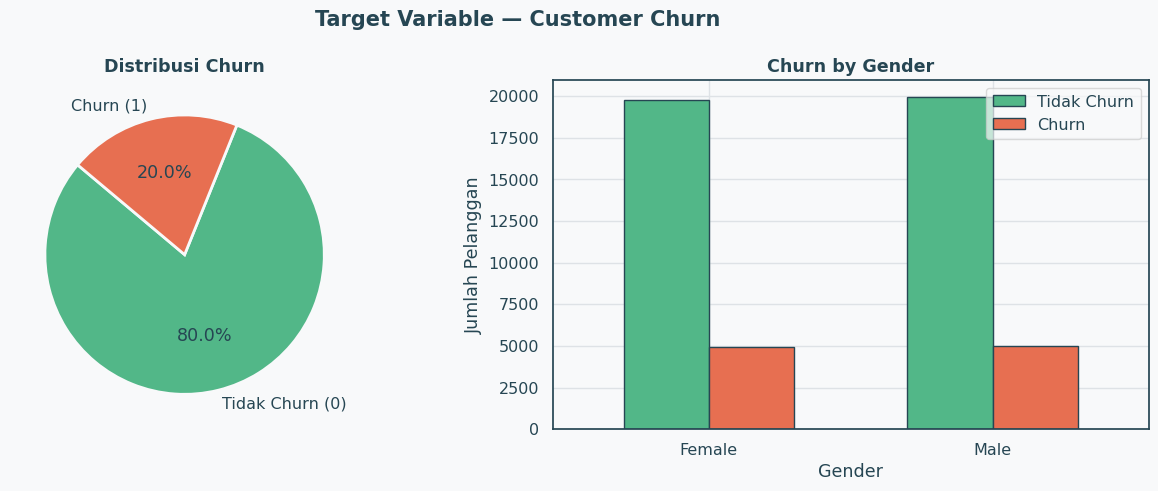

In [86]:
#── Plot A: Target distribution ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Target Variable — Customer Churn", fontsize=15, fontweight="bold", color=DARK)

churn_counts = cust["churn"].value_counts()
labels = ["Tidak Churn (0)", "Churn (1)"]
colors_pie = [SECONDARY, DANGER]
axes[0].pie(churn_counts.values, labels=labels, colors=colors_pie,
            autopct="%1.1f%%", startangle=140,
            wedgeprops=dict(edgecolor=LIGHT_BG, linewidth=2))
axes[0].set_title("Distribusi Churn", fontweight="bold")

churn_by_gender = cust.groupby(["gender","churn"]).size().unstack()
churn_by_gender.plot(kind="bar", ax=axes[1], color=[SECONDARY, DANGER],
                     edgecolor=DARK, width=0.6)
axes[1].set_title("Churn by Gender", fontweight="bold")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Jumlah Pelanggan")
axes[1].legend(["Tidak Churn","Churn"], framealpha=0.7)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
save(fig, "01_target_distribution.png")
plt.show()

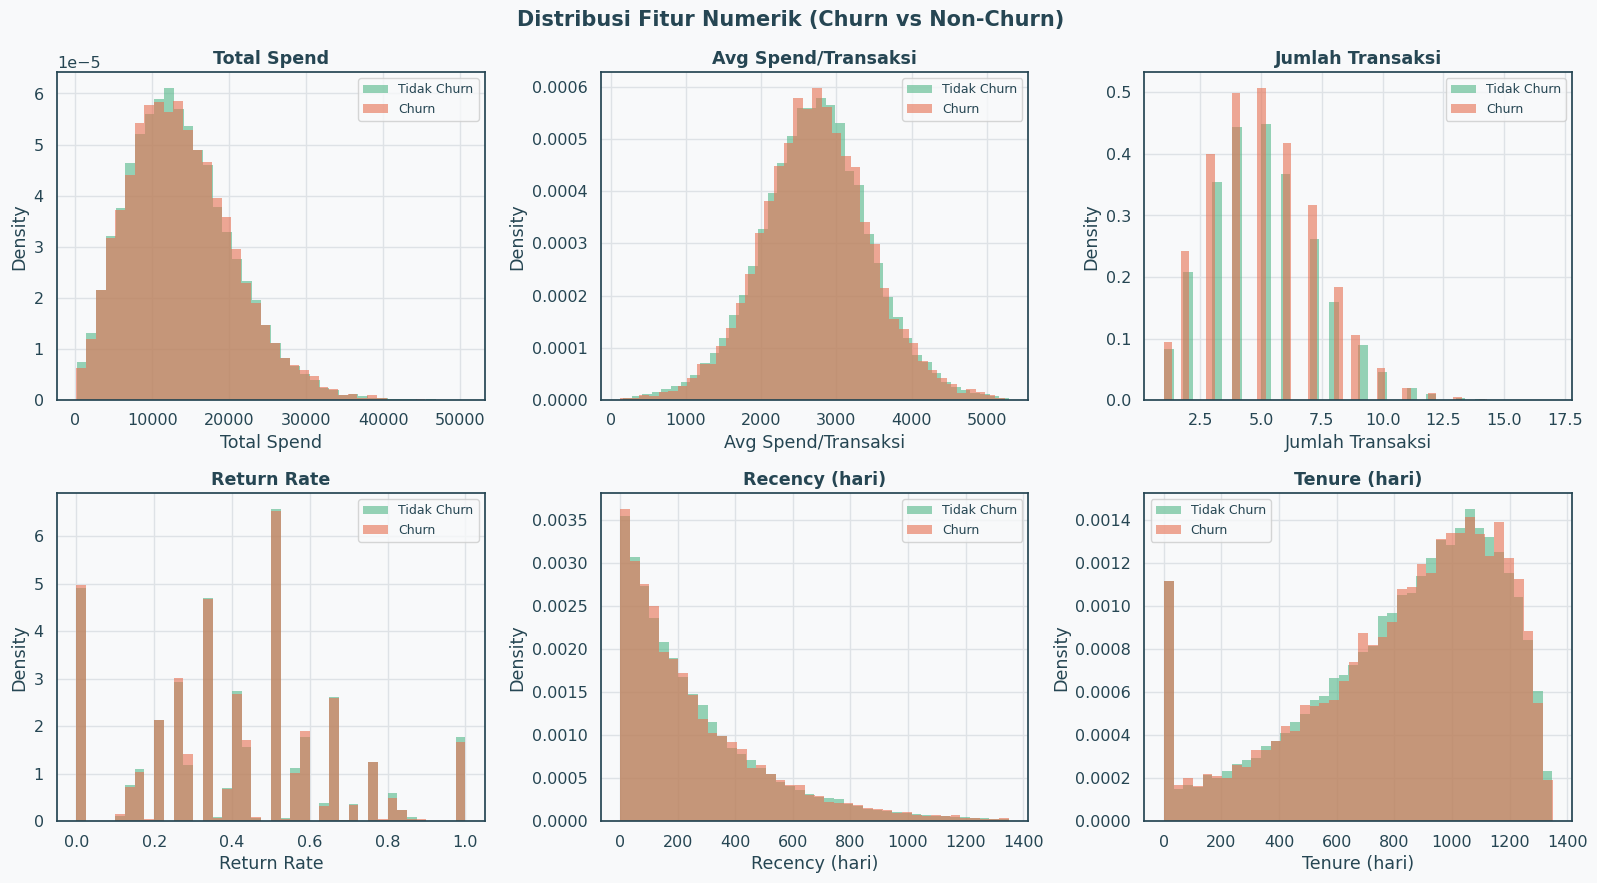

  ✓ Saved 02_numeric_distributions.png


In [92]:
# ── Plot B: Numerical distributions ─────────────────────────
num_cols = ["total_spend","avg_spend","num_transactions",
            "return_rate","recency_days","tenure_days"]
labels_map = {
    "total_spend":"Total Spend",
    "avg_spend":"Avg Spend/Transaksi",
    "num_transactions":"Jumlah Transaksi",
    "return_rate":"Return Rate",
    "recency_days":"Recency (hari)",
    "tenure_days":"Tenure (hari)"
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distribusi Fitur Numerik (Churn vs Non-Churn)", fontsize=15,
             fontweight="bold", color=DARK)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in zip([0,1],[SECONDARY, DANGER]):
        subset = cust[cust["churn"]==label][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color,
                     edgecolor="none", label=["Tidak Churn","Churn"][label],
                     density=True)
    axes[i].set_title(labels_map[col], fontweight="bold")
    axes[i].set_xlabel(labels_map[col])
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.show()
save(fig, "02_numeric_distributions.png")

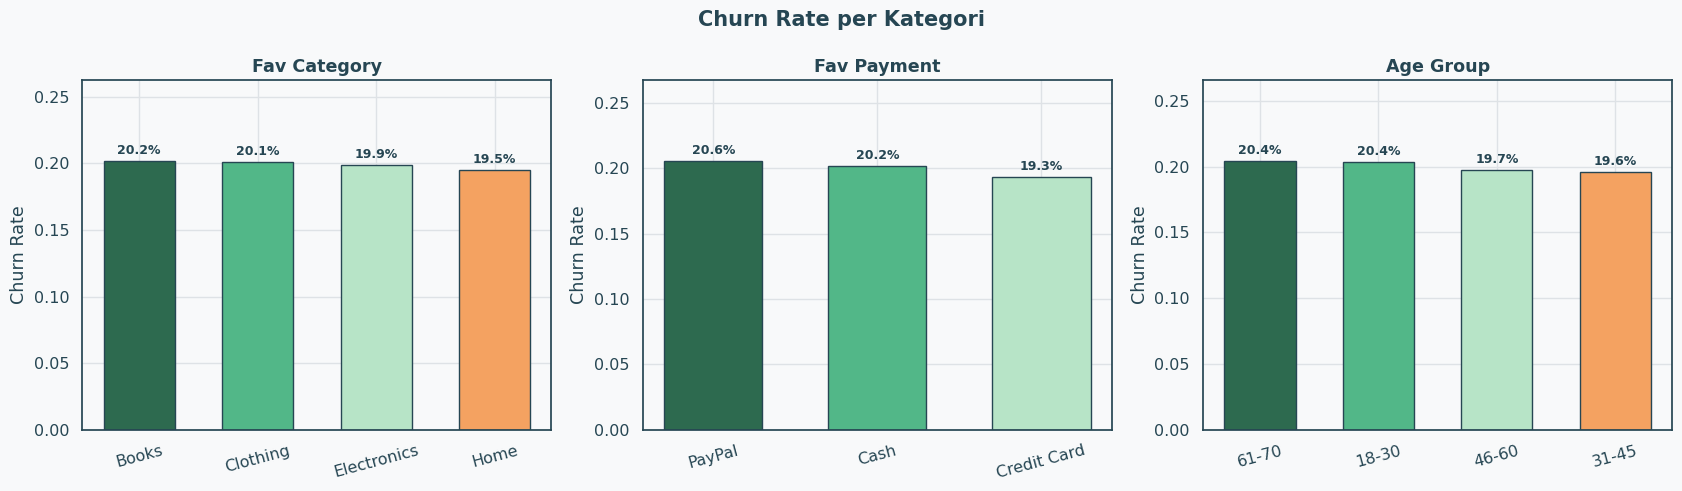

  ✓ Saved 03_categorical_churn.png


In [94]:
# ── Plot C: Categorical analysis ─────────────────────────────
cat_cols = ["fav_category","fav_payment","age_group"]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Churn Rate per Kategori", fontsize=15, fontweight="bold", color=DARK)

for i, col in enumerate(cat_cols):
    churn_rate = cust.groupby(col)["churn"].mean().sort_values(ascending=False)
    bars = axes[i].bar(churn_rate.index.astype(str), churn_rate.values,
                       color=PALETTE[:len(churn_rate)], edgecolor=DARK, width=0.6)
    axes[i].set_title(col.replace("_"," ").title(), fontweight="bold")
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_ylim(0, churn_rate.max() * 1.3)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                     f"{val:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
save(fig, "03_categorical_churn.png")

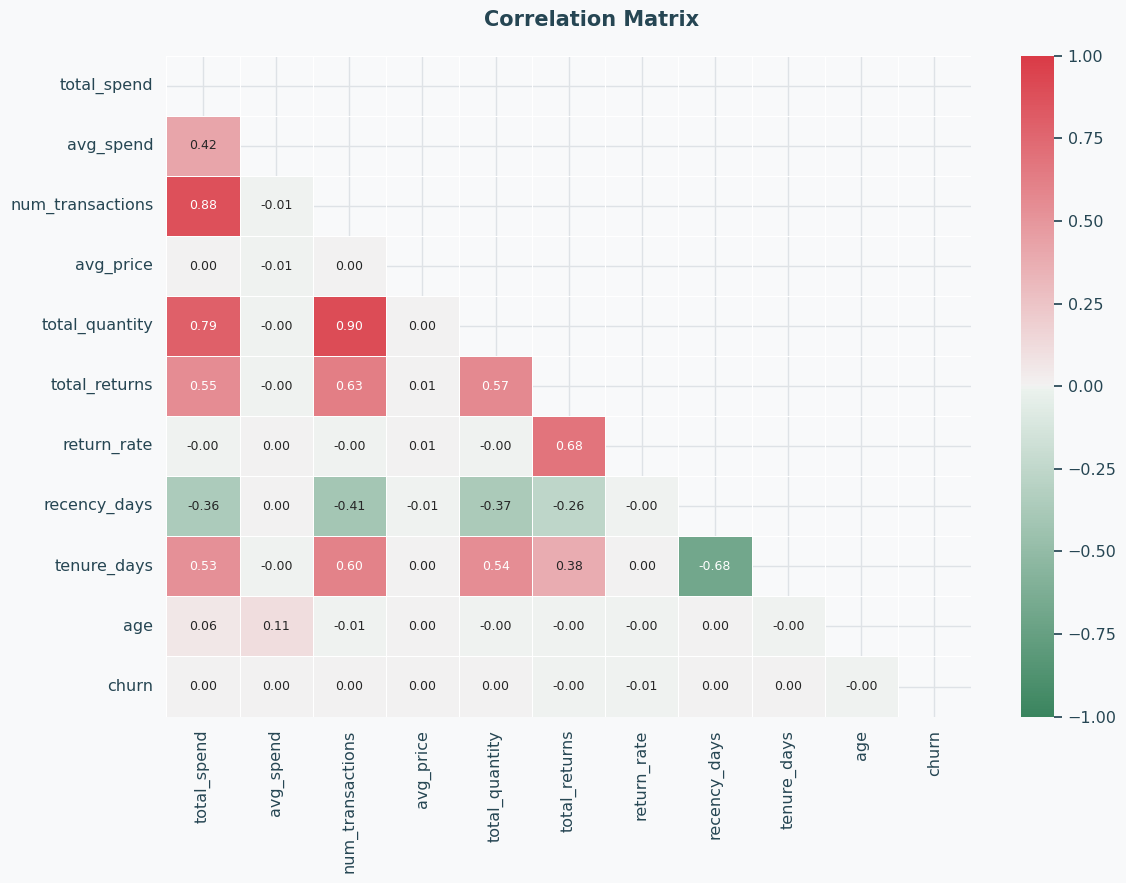

  ✓ Saved 04_correlation_heatmap.png


In [98]:
# ── Plot D: Correlation heatmap ──────────────────────────────
num_features = ["total_spend","avg_spend","num_transactions","avg_price",
                "total_quantity","total_returns","return_rate","recency_days",
                "tenure_days","age","churn"]
corr = cust[num_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle("Correlation Matrix", fontsize=15, fontweight="bold", color=DARK)
cmap = sns.diverging_palette(145, 10, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=cmap, annot=True, fmt=".2f",
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={"size":9})
ax.set_title("")
plt.tight_layout()
plt.show()
save(fig, "04_correlation_heatmap.png")

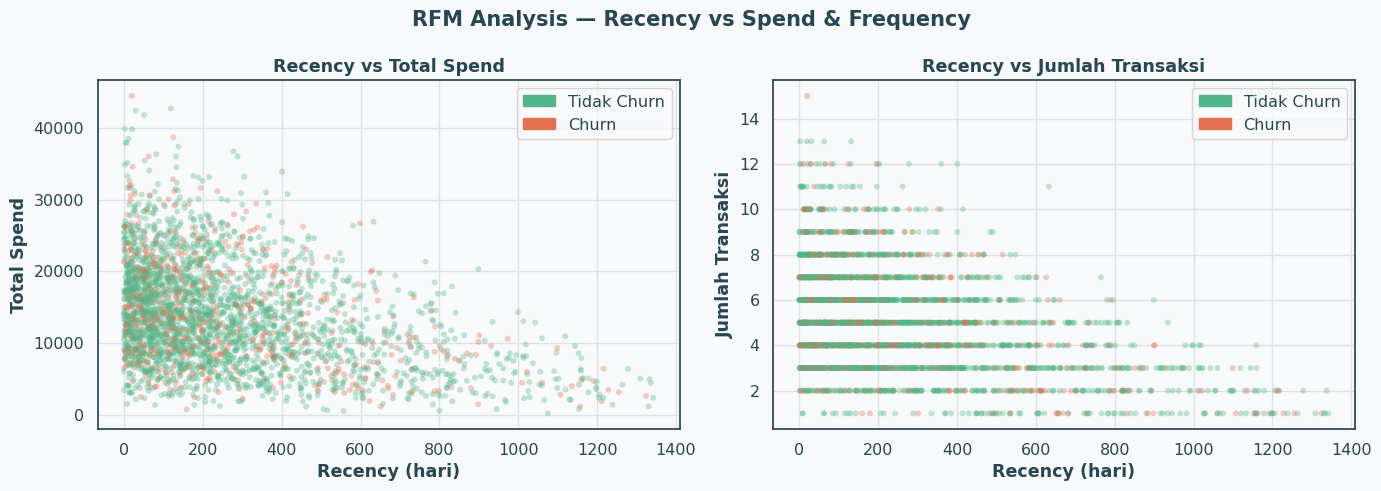

  ✓ Saved 05_rfm_scatter.png


In [100]:
# ── Plot E: RFM-style scatterplot ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("RFM Analysis — Recency vs Spend & Frequency", fontsize=15,
             fontweight="bold", color=DARK)

for ax, (y_col, y_lbl) in zip(axes, [("total_spend","Total Spend"),
                                      ("num_transactions","Jumlah Transaksi")]):
    sample = cust.sample(min(3000, len(cust)), random_state=42)
    colors_map = sample["churn"].map({0: SECONDARY, 1: DANGER})
    ax.scatter(sample["recency_days"], sample[y_col], c=colors_map,
               alpha=0.35, s=18, edgecolors="none")
    ax.set_xlabel("Recency (hari)", fontweight="bold")
    ax.set_ylabel(y_lbl, fontweight="bold")
    ax.set_title(f"Recency vs {y_lbl}", fontweight="bold")
    # legend patches
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=SECONDARY, label="Tidak Churn"),
                        Patch(color=DANGER, label="Churn")],
              framealpha=0.8)

plt.tight_layout()
plt.show()
save(fig, "05_rfm_scatter.png")